In [1]:
from common.setup_plotting import setup_matplotlib, get_figure_dir
from common.data_downloader import download_data
from dataset import get_dataloaders

import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, r2_score

setup_matplotlib()        # configure matplotlib first (So i can use LaTeX in the labels)
# Make interactive plots work in Jupyter notebooks 
%matplotlib inline 
import matplotlib.pyplot as plt   # THEN import pyplot


/home/aaki/.local/conda/envs/deepLearning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Missing colon in file PosixPath('/home/aaki/Documents/gitRepos/Advanced_DeepLearning_Seminar/latex/matplotlibrc'), line 21 ("    '#4C72B0',  # blue")
Missing colon in file PosixPath('/home/aaki/Documents/gitRepos/Advanced_DeepLearning_Seminar/latex/matplotlibrc'), line 22 ("    '#DD8452',  # orange")
Missing colon in file PosixPath('/home/aaki/Documents/gitRepos/Advanced_DeepLearning_Seminar/latex/matplotlibrc'), line 23 ("    '#55A868',  # green")
Missing colon in file PosixPath('/home/aaki/Documents/gitRepos/Advanced_DeepLearning_Seminar/latex/matplotlibrc'), line 24 ("    '#C44E52',  # red")
Missing colon in file PosixPath('/home/aaki/Documents/gitRepos/Advanced_DeepLearning_Seminar/latex/matplotlibrc'), line 25

In [2]:
# download data for this task, if needed and get path
data_path = download_data("task_01")
# get and if needed create figure directory for this task
fig_dir = get_figure_dir("task_01")

task_01 data already available.


In [3]:
spectra = np.load(f"{data_path}/spectra.npy")
spectra_length = spectra.shape[1]

# labels: mass, age, l_bol, dist, t_eff, log_g, fe_h, SNR
labelNames = ["mass", "age", "l_bol", "dist", "t_eff", "log_g", "fe_h", "SNR"]
labels = np.load(f"{data_path}/labels.npy")

# We only use the three labels: t_eff, log_g, fe_h
labelNames = labelNames[-4:-1]
labels = labels[:, -4:-1]
n_labels = labels.shape[1]

In [4]:
def plot_spectrum(ax, spectrum, labels, labelName):
    ax.plot(spectrum, label=labelName)

    ax.set_xlabel("Wavelength")
    ax.set_ylabel("Flux")

    ax.set_title(
        rf"$T_{{\mathrm{{eff}}}}$: {labels[0]:.2f}, "
        rf"$\log(g)$: {labels[1]:.2f}, "
        rf"$[\mathrm{{Fe}}/\mathrm{{H}}]$: {labels[2]:.2f}"
    )
    ax.legend()

# Understanding the data
print("Spectra shape:", spectra.shape)
print("Labels shape:", labels.shape)
print("Label names:", labelNames)

print("\nExample spectrum (first row):", spectra[0])
print("Example labels (first row):", labels[0])


Spectra shape: (8914, 16384)
Labels shape: (8914, 3)
Label names: ['t_eff', 'log_g', 'fe_h']

Example spectrum (first row): [0.98187202 0.98642796 1.00678337 ... 1.06921351 1.11236954 1.22603142]
Example labels (first row): [ 5.6880371e+03  4.4140868e+00 -1.8493813e-01]


/tmp/ipykernel_15463/221323728.py:8: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Now the same plots for log values of the spectra standardized and standardize labels:


/tmp/ipykernel_15463/221323728.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


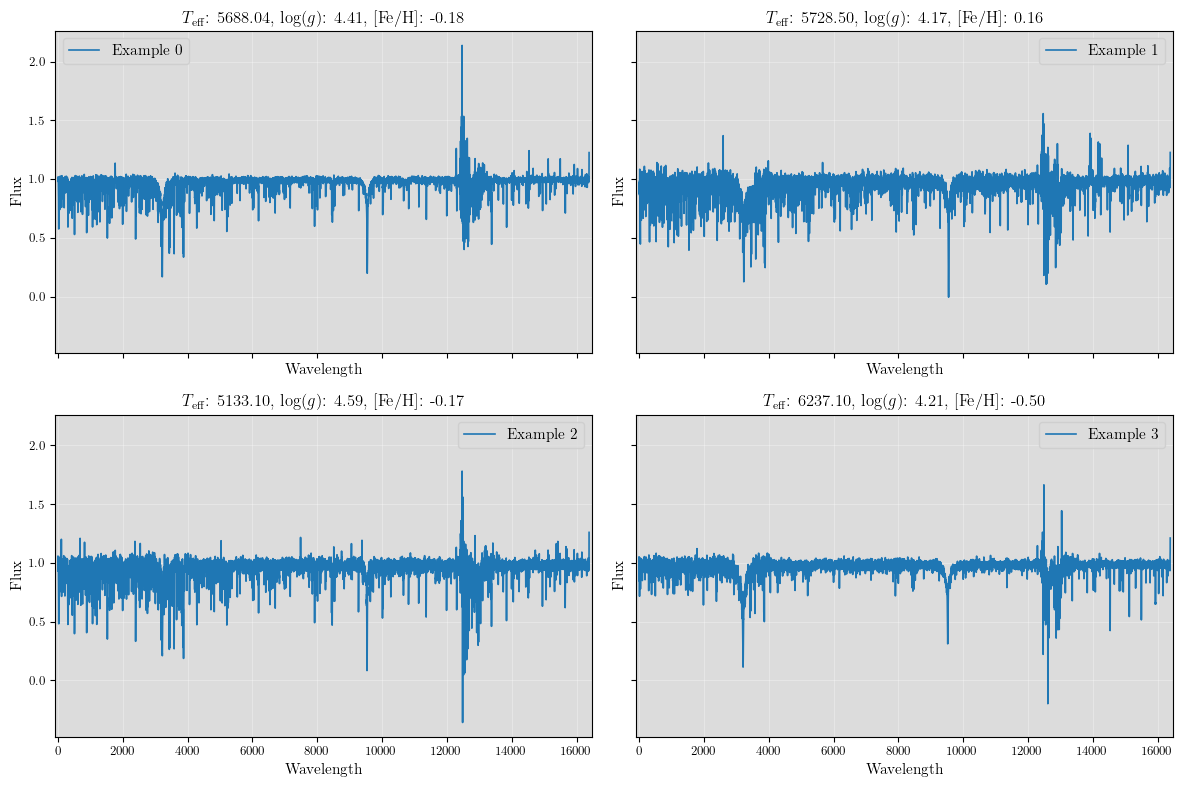

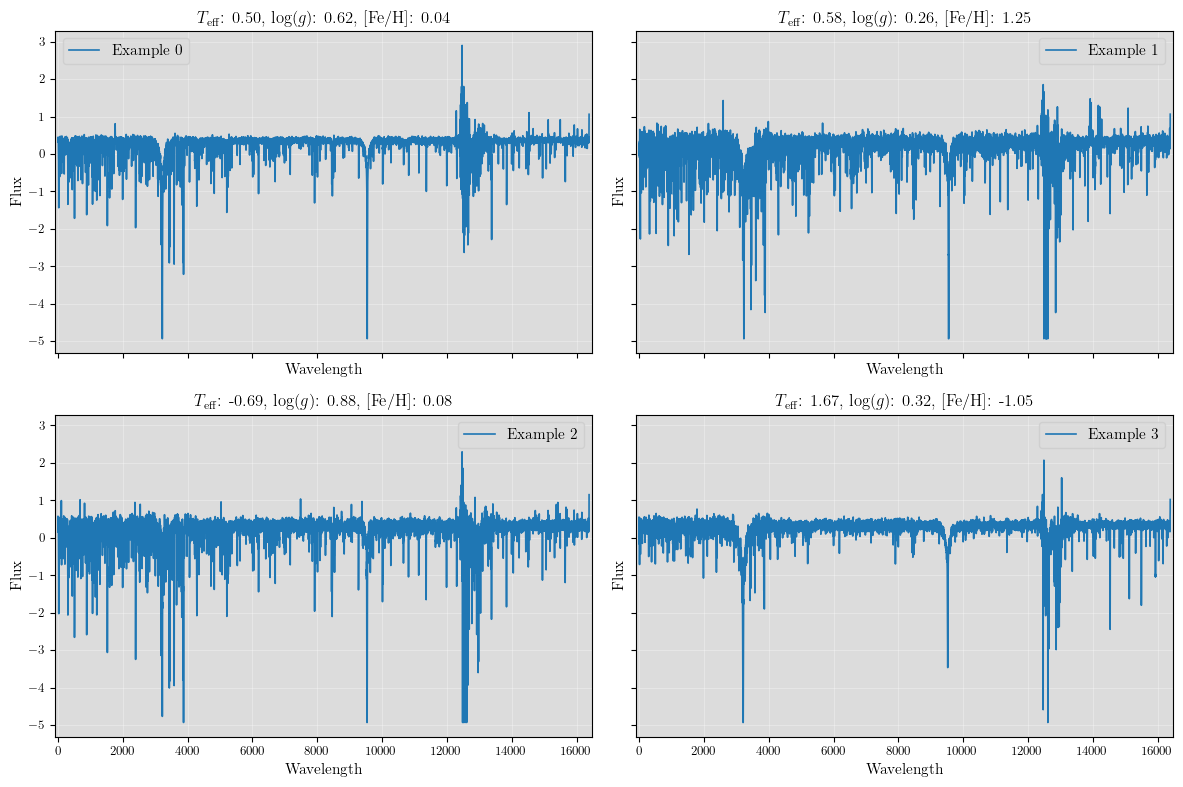

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

example_indices = [0, 1, 2, 3]

for ax, idx in zip(axes.flat, example_indices):
    plot_spectrum(ax, spectra[idx], labels[idx], labelName=f"Example {idx}")

fig.tight_layout()
fig.savefig(f"{fig_dir}/example_spectra.pdf")

print("Now the same plots for log values of the spectra standardized and standardize labels:")

# ensure everything is positive before taking log, to avoid -inf values
spectra_log = np.log(np.maximum(spectra, 0.2))

x_mean = spectra_log.mean()
x_std = spectra_log.std()
spectra_norm = (spectra_log - x_mean) / x_std

# standardize labels as well
labels_mean = labels.mean(axis=0)
labels_std = labels.std(axis=0)
labels_norm = (labels - labels_mean) / labels_std

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, idx in zip(axes.flat, example_indices):
    plot_spectrum(ax, spectra_norm[idx], labels_norm[idx], labelName=f"Example {idx}")
fig.tight_layout()
fig.savefig(f"{fig_dir}/example_spectra_normed.pdf")
None

/tmp/ipykernel_15463/776212972.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


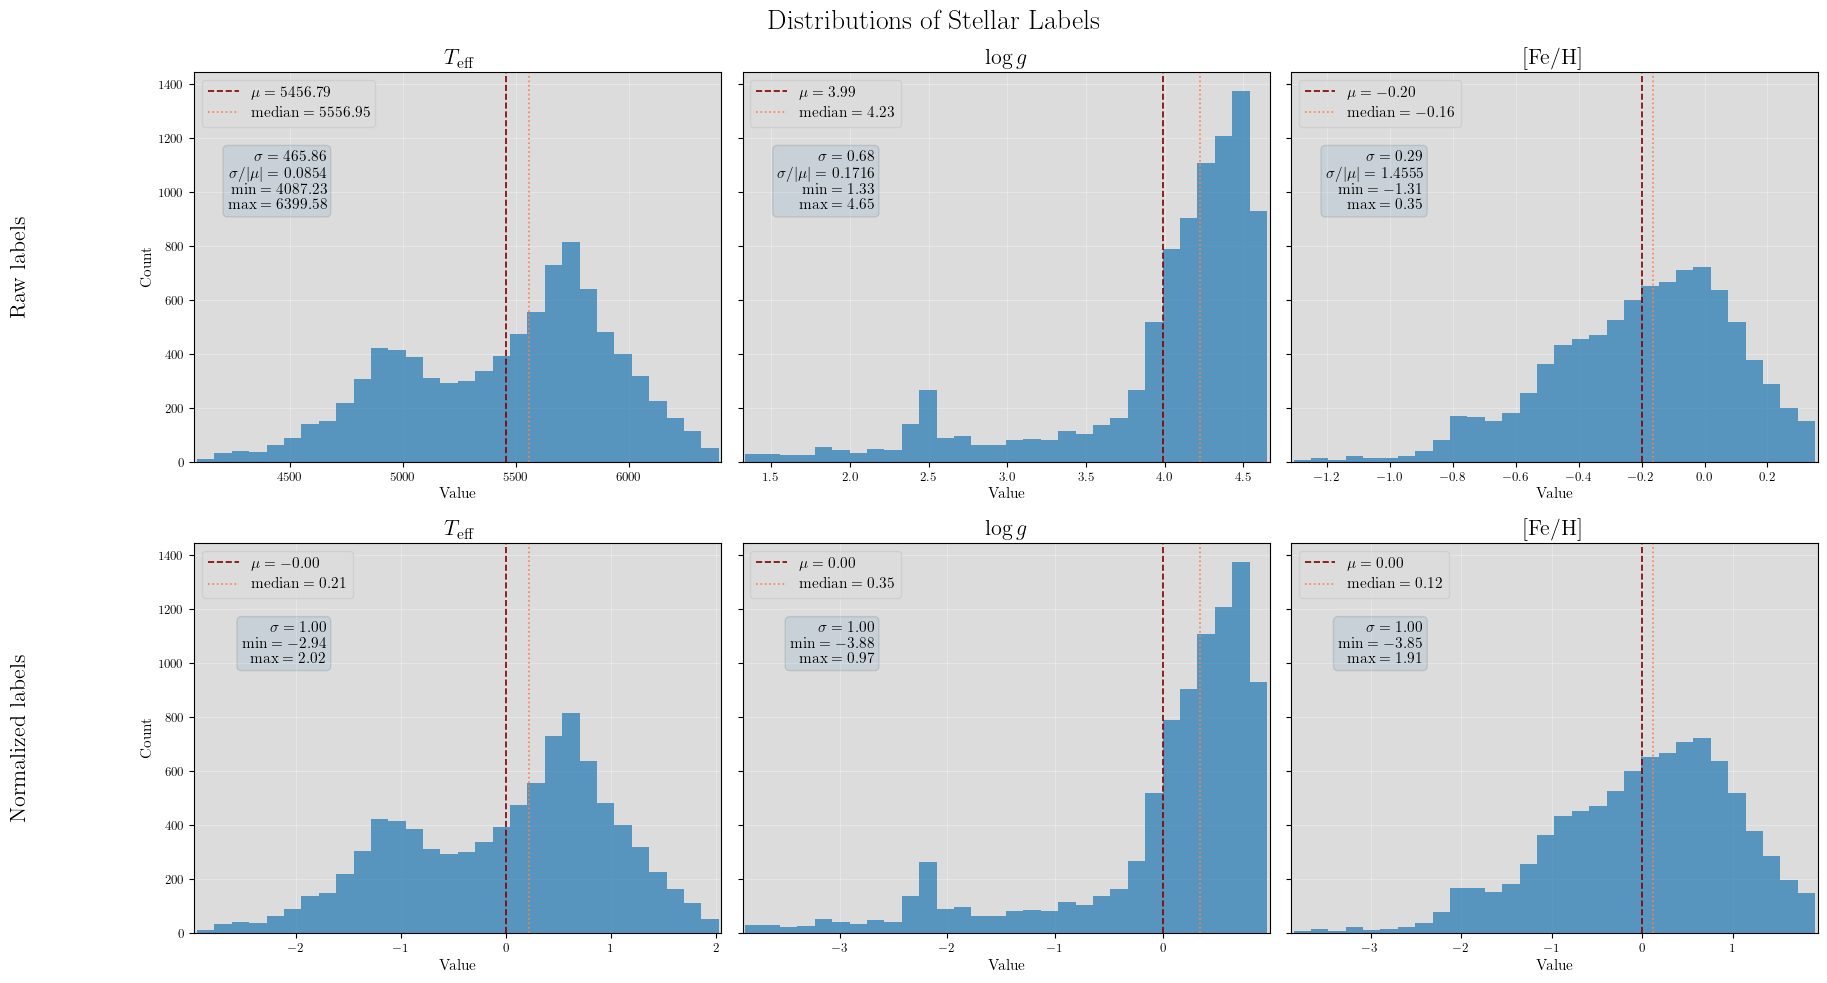

In [6]:
# Plot distributions of raw and normalized labels
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")

latex_names = [
    r"$T_{\mathrm{eff}}$",
    r"$\log g$",
    r"$[\mathrm{Fe}/\mathrm{H}]$",
]

datasets = [
    (labels, "Raw labels", True),
    (labels_norm, "Normalized labels", False),
]

for row, (data, row_title, show_norm_std) in enumerate(datasets):

    for i in range(n_labels):
        ax = axes[row, i]

        values = data[:, i]

        # histogram
        ax.hist(values, bins=30, color="C0", alpha=0.7)

        # statistics
        mean_val = np.mean(values)
        median_val = np.median(values)
        std_val = np.std(values)
        min_val = np.min(values)
        max_val = np.max(values)

        # vertical lines
        ax.axvline(
            mean_val,
            linestyle="--",
            color="maroon",
            label=rf"$\mu = {mean_val:.2f}$"
        )

        ax.axvline(
            median_val,
            linestyle=":",
            color="coral",
            label=rf"$\mathrm{{median}} = {median_val:.2f}$"
        )

        # labels
        ax.set_title(latex_names[i], fontsize=16)
        ax.set_xlabel(r"Value")

        if i == 0:
            ax.set_ylabel(r"Count")

        # stats text
        stats_text = (
            rf"$\sigma = {std_val:.2f}$" "\n"
            rf"$\min = {min_val:.2f}$" "\n"
            rf"$\max = {max_val:.2f}$"
        )

        if show_norm_std:
            norm_std = std_val / np.abs(mean_val)

            stats_text = (
                rf"$\sigma = {std_val:.2f}$" "\n"
                rf"$\sigma / |\mu| = {norm_std:.4f}$" "\n"
                rf"$\min = {min_val:.2f}$" "\n"
                rf"$\max = {max_val:.2f}$"
            )

        ax.text(
            0.25,
            0.8,
            stats_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(boxstyle="round", alpha=0.1),
        )

        ax.legend(loc="upper left")

    axes[row, 0].text(
        -0.35,
        0.5,
        row_title,
        transform=axes[row, 0].transAxes,
        rotation=90,
        va="center",
        fontsize=16,
    )

fig.suptitle(r"Distributions of Stellar Labels", fontsize=20)

fig.tight_layout()
fig.savefig(f"{fig_dir}/label_distributions.pdf")

In [7]:
train_loader, val_loader, test_loader = get_dataloaders(spectra_norm, labels_norm, batch_size=64, val_split=0.2, test_split=0.1)

In [8]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape

(torch.Size([64, 1, 16384]), torch.Size([64, 3]))

In [9]:
class SpectraCNN(nn.Module):
    def __init__(self, input_length, n_labels=3):
        super().__init__()

        out_channels = [16, 32, 64]
        kernel_sizes = [9, 9, 9]
        paddings = [4, 4, 4]

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=out_channels[0], kernel_size=kernel_sizes[0], padding=paddings[0]),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4), # has stride equal to kernel size by default so reduces length by factor of 4

            nn.Conv1d(out_channels[0], out_channels[1], kernel_size=kernel_sizes[1], padding=paddings[1]),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(out_channels[1], out_channels[2], kernel_size=kernel_sizes[2], padding=paddings[2]),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )

        final_length = input_length // (4**3)  # after 3 pooling layers with kernel size 4

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels[2] * final_length, 128),
            nn.ReLU(),
            nn.Linear(128, n_labels),
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.head(x)
        return x

In [10]:
# Check device availability
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

model = SpectraCNN(input_length=spectra_length, n_labels=n_labels).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


Using device: cuda


In [11]:
skip_training = True # Set to True to skip the training after having trained the model once

# Train the model
num_epochs = 60
train_losses, val_losses = [], []

best_val_loss = float("inf")

patience = 10
epochs_without_improvement = 0

# File where the complete checkpoint will be stored
best_model_path = "../models/model_checkpoint_best.pth"

for epoch in range(num_epochs):
    if skip_training:
        print("Skipping training loop as skip_training is set to True.")
        break
    # switch to training mode
    model.train()

    train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch_x, batch_y in progress_bar:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        predictions = model(batch_x)

        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # switch to evaluation mode for validation
    model.eval()

    val_loss = 0

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)

            loss = loss_fn(predictions, batch_y)

            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # This stores the complete checkpoint with all relevant information, not just model weights, 
    # so we can resume training or analyze later without needing to retrain everything from scratch.
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        checkpoint = {

            # current epoch
            "epoch": epoch + 1,

            # model parameters
            "model_state_dict": model.state_dict(),

            # optimizer parameters
            "optimizer_state_dict": optimizer.state_dict(),

            # loss curves
            "train_losses": train_losses,
            "val_losses": val_losses,

            # best validation performance
            "best_val_loss": best_val_loss,
        }

        torch.save(checkpoint, best_model_path)

        print(f"Saved best model: val_loss={val_loss:.4f}")

    else:

        epochs_without_improvement += 1

        print(f"No improvement: {epochs_without_improvement}/{patience}")

    # Early stopping 
    if epochs_without_improvement >= patience:

        checkpoint = torch.load(best_model_path)

        # Update checkpoint with final training information before stopping
        checkpoint["train_losses"] = train_losses
        checkpoint["val_losses"] = val_losses
        checkpoint["stopped_epoch"] = epoch + 1
        checkpoint["patience"] = patience

        torch.save(checkpoint, best_model_path)

        print(f"Early stopping at epoch {epoch+1}")
        break

Skipping training loop as skip_training is set to True.


In [12]:
# Load checkpoint and analyze results (without needing to retrain everything from scratch when rerunning this notebook)

checkpoint = torch.load(
    "../models/model_checkpoint_best.pth",
    map_location=device,
)

print("Best validation loss:", checkpoint["best_val_loss"])
print("Checkpoint epoch:", checkpoint["epoch"])

# load loss curves
train_losses = checkpoint["train_losses"]
val_losses = checkpoint["val_losses"]

Best validation loss: 0.02457904469754015
Checkpoint epoch: 30


/tmp/ipykernel_15463/581154524.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Test Loss: 0.0108


/tmp/ipykernel_15463/2994297709.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


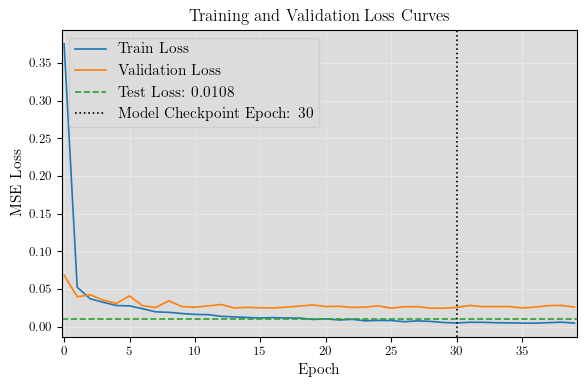

In [13]:
# recreate model architecture
model = SpectraCNN(input_length=spectra_length, n_labels=n_labels).to(device)

# load learned weights
model.load_state_dict(checkpoint["model_state_dict"])

# switch to evaluation mode
model.eval()

# Evaluate on test set
test_loss = 0
predictions_list = []
true_labels_list = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        predictions = model(batch_x)
        predictions_list.append(predictions.cpu())
        true_labels_list.append(batch_y.cpu())

        loss = loss_fn(predictions, batch_y)

        test_loss += loss.item()

# Concatenate all predictions and true labels into single tensors for further analysis or plotting
preds = torch.cat(predictions_list, dim=0)
truths = torch.cat(true_labels_list, dim=0)

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

# Train and validation loss curves
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(train_losses, label="Train Loss", color="C0")
ax.plot(val_losses, label="Validation Loss", color="C1")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training and Validation Loss Curves")
ax.axhline(test_loss, color="C2", linestyle="--", label=f"Test Loss: {test_loss:.4f}")
ax.axvline(
    checkpoint["epoch"],
    color="black",
    linestyle=":",
    label=f"Model Checkpoint Epoch: {checkpoint['epoch']}"
)
ax.legend()
fig.tight_layout()
fig.savefig(f"{fig_dir}/loss_curves.pdf")
None


/tmp/ipykernel_15463/3801677823.py:51: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


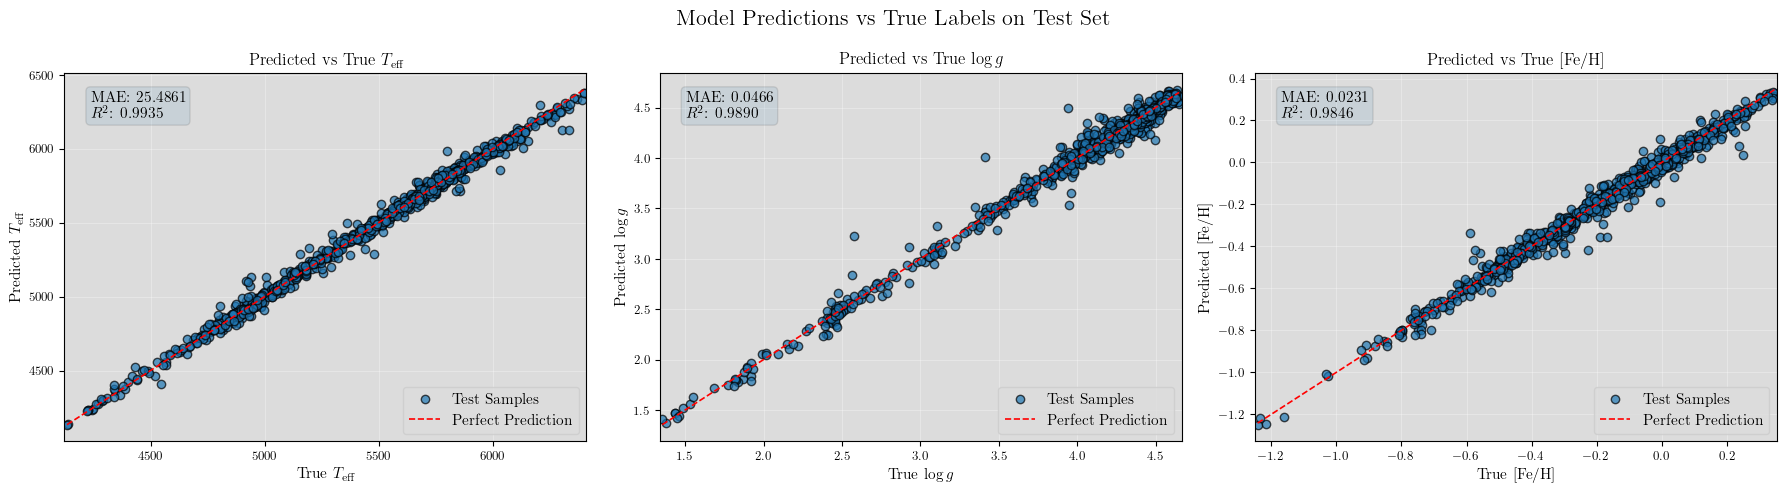

In [14]:
# convert predictions and labels back to original scale
predictions_orig = np.asarray(preds) * labels_std + labels_mean
true_labels_orig = np.asarray(truths )* labels_std + labels_mean

# Scatter plots of predictions vs true labels for each parameter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
latex_names = [
    r"$T_{\mathrm{eff}}$",
    r"$\log g$",
    r"$[\mathrm{Fe}/\mathrm{H}]$",
]
for i in range(n_labels):
    ax = axes[i]
    ax.scatter(
        true_labels_orig[:, i],
        predictions_orig[:, i],
        alpha=0.7,
        color="C0",
        edgecolor="k",
        label="Test Samples"
    )
    ax.plot(
        [true_labels_orig[:, i].min(), true_labels_orig[:, i].max()],
        [true_labels_orig[:, i].min(), true_labels_orig[:, i].max()],
        color="red",
        linestyle="--",
        label="Perfect Prediction"
    )
    ax.set_xlabel(f"True {latex_names[i]}")
    ax.set_ylabel(f"Predicted {latex_names[i]}")
    ax.set_title(f"Predicted vs True {latex_names[i]}")


    # Compute numerical metrics like MAE and R^2 for each parameter and add them as text annotations on the plot
    mae = mean_absolute_error(true_labels_orig[:, i], predictions_orig[:, i])
    r2 = r2_score(true_labels_orig[:, i], predictions_orig[:, i])
    metrics_text = f"MAE: {mae:.4f}\n$R^2$: {r2:.4f}"
    ax.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", alpha=0.1),
    )
    ax.legend()

fig.suptitle("Model Predictions vs True Labels on Test Set", fontsize=16)
fig.tight_layout()
fig.savefig(f"{fig_dir}/predictions_vs_true.pdf")
